# Importing Required Libraries

In [ ]:
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
import seaborn as sns
import matplotlib.pyplot as plt


# Loading the ACN Dataset

The ACN charging session dataset is loaded to understand its structure, dimensions, and available features before preprocessing. Basic inspection helps identify charging session variables, timestamp columns, and operational metrics required for demand forecasting and dynamic tariff optimization.

In [2]:
# Load dataset
df = pd.read_excel("dataset/ACN/acndata_sessions.json.xlsx")

# View basic info
print(df.shape)

# View columns
print(df.columns)

# Preview data
df.head()

(16304, 27)
Index(['_meta', 'end', 'min_kWh', 'site', 'start', '_items', '_id',
       'clusterID', 'connectionTime', 'disconnectTime', 'doneChargingTime',
       'kWhDelivered', 'sessionID', 'siteID', 'spaceID', 'stationID',
       'timezone', 'userID', 'userInputs', 'WhPerMile', 'kWhRequested',
       'milesRequested', 'minutesAvailable', 'modifiedAt', 'paymentRequired',
       'requestedDeparture', 'userID.1'],
      dtype='object')


,_meta,end,min_kWh,site,start,_items,_id,clusterID,connectionTime,disconnectTime,...,userID,userInputs,WhPerMile,kWhRequested,milesRequested,minutesAvailable,modifiedAt,paymentRequired,requestedDeparture,userID.1
0,NaN,NaN,NaN,caltech,NaN,NaN,5bc90cb9f9af8b0d7fe77cd2,39.0,"Wed, 25 Apr 2018 11:08:04 GMT","Wed, 25 Apr 2018 13:20:10 GMT",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,5bc90cb9f9af8b0d7fe77cd3,39.0,"Wed, 25 Apr 2018 13:45:10 GMT","Thu, 26 Apr 2018 00:56:16 GMT",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,5bc90cb9f9af8b0d7fe77cd4,39.0,"Wed, 25 Apr 2018 13:45:50 GMT","Wed, 25 Apr 2018 23:04:45 GMT",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,5bc90cb9f9af8b0d7fe77cd5,39.0,"Wed, 25 Apr 2018 14:37:06 GMT","Wed, 25 Apr 2018 23:55:34 GMT",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,5bc90cb9f9af8b0d7fe77cd6,39.0,"Wed, 25 Apr 2018 14:40:34 GMT","Wed, 25 Apr 2018 23:03:12 GMT",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Converting Timestamp Columns

- The timestamp columns are converted into proper datetime format to enable time-based analysis and preprocessing.  
- This step is essential for calculating charging durations, idle times, hourly demand patterns, and utilization metrics.  
- Using `errors='coerce'` ensures that invalid or corrupted timestamps are safely handled without interrupting the workflow.

In [3]:
# Timestamp columns
time_cols = [
    'connectionTime',
    'disconnectTime',
    'doneChargingTime',
    'start',
    'end',
    'modifiedAt'
]

# Convert to datetime
for col in time_cols:
    df[col] = pd.to_datetime(df[col], errors='coerce')

# Check data types
df[time_cols].dtypes

connectionTime      datetime64[ns]
disconnectTime      datetime64[ns]
doneChargingTime    datetime64[ns]
start               datetime64[ns]
end                 datetime64[ns]
modifiedAt          datetime64[ns]
dtype: object

### Feature Engineering: Duration Metrics

- Charging duration measures the actual time an EV spent actively charging.  
- Parking duration represents the total time the vehicle occupied the charging station.  
- Idle time captures the period after charging completion while the vehicle still occupied the charger.  



In [4]:
# Charging duration
df['charging_duration_min'] = (
    df['doneChargingTime'] -
    df['connectionTime']
).dt.total_seconds() / 60

# Total parking duration
df['parking_duration_min'] = (
    df['disconnectTime'] -
    df['connectionTime']
).dt.total_seconds() / 60

# Idle time after charging completed
df['idle_time_min'] = (
    df['disconnectTime'] -
    df['doneChargingTime']
).dt.total_seconds() / 60

# Quick check
df[[
    'charging_duration_min',
    'parking_duration_min',
    'idle_time_min'
]].describe()

,charging_duration_min,parking_duration_min,idle_time_min
count,14991.000000,14999.000000,14991.000000
mean,194.184634,355.417856,161.381889
std,191.115051,387.567420,323.746761
min,-41.366667,5.250000,-1.000000
25%,76.308333,121.508333,0.083333
50%,134.500000,285.850000,44.383333
75%,254.666667,523.783333,251.191667
max,6265.700000,14716.150000,9367.283333


In [5]:
# Keep only logically valid sessions
df_clean = df[
    (df['charging_duration_min'] > 0) &
    (df['parking_duration_min'] > 0) &
    (df['idle_time_min'] >= 0)
].copy()

# Remove extreme outliers
# (Using practical operational thresholds)

df_clean = df_clean[
    (df_clean['charging_duration_min'] <= 1440) &   # <= 24 hours
    (df_clean['parking_duration_min'] <= 1440) &
    (df_clean['idle_time_min'] <= 720)              # <= 12 hours
]

# Check remaining data
print(df_clean.shape)

# Recheck statistics
df_clean[[
    'charging_duration_min',
    'parking_duration_min',
    'idle_time_min'
]].describe()

(13879, 30)


,charging_duration_min,parking_duration_min,idle_time_min
count,13879.000000,13879.000000,13879.000000
mean,182.419985,321.086863,138.666878
std,153.757800,225.130961,175.381570
min,0.433333,5.250000,0.000000
25%,74.541667,118.058333,0.133333
50%,131.350000,276.833333,50.450000
75%,242.933333,517.291667,247.583333
max,1409.366667,1424.250000,719.383333


### Temporal Feature Engineering

- Time-based features were extracted from charging session timestamps to capture temporal charging behavior patterns.  
- Features such as hour, day of week, month, and weekend indicators help identify:
  - peak demand periods,
  - weekday vs weekend behavior,
  - seasonal trends,
  - and congestion patterns.  

- Hourly timestamp aggregation was also created to support:
  - demand forecasting,
  - utilization analysis,
  - and dynamic tariff optimization.

In [6]:
# Hour of day
df_clean['hour'] = (
    df_clean['connectionTime'].dt.hour
)

# Day of week
# Monday=0, Sunday=6
df_clean['day_of_week'] = (
    df_clean['connectionTime'].dt.dayofweek
)

# Month
df_clean['month'] = (
    df_clean['connectionTime'].dt.month
)

# Weekend indicator
df_clean['is_weekend'] = (
    df_clean['day_of_week'] >= 5
).astype(int)

# Date only
df_clean['date'] = (
    df_clean['connectionTime'].dt.date
)

# Hourly timestamp bucket
df_clean['timestamp_hour'] = (
    df_clean['connectionTime']
    .dt.floor('H')
)

# Check
df_clean[[
    'connectionTime',
    'hour',
    'day_of_week',
    'month',
    'is_weekend',
    'timestamp_hour'
]].head()

,connectionTime,hour,day_of_week,month,is_weekend,timestamp_hour
1,2018-04-25 13:45:10,13,2,4,0,2018-04-25 13:00:00
2,2018-04-25 13:45:50,13,2,4,0,2018-04-25 13:00:00
3,2018-04-25 14:37:06,14,2,4,0,2018-04-25 14:00:00
4,2018-04-25 14:40:34,14,2,4,0,2018-04-25 14:00:00
5,2018-04-25 14:43:50,14,2,4,0,2018-04-25 14:00:00


### Building the Hourly Analytical Base

- Charging session data was aggregated at the station-hour level to create a unified analytical base for forecasting and pricing analysis.  
- Key operational metrics such as session count, energy delivered, charging duration, idle time, and estimated revenue were computed for each station-hour interval.  
- A baseline tariff of ₹15/kWh was used to estimate charging revenue under static pricing conditions.  

- Charger utilization rate was approximated using average charging duration within each hourly interval and normalized between 0 and 1.  



In [7]:
# Baseline tariff
BASE_TARIFF = 15

# Revenue estimate
df_clean['revenue_baseline'] = (
    df_clean['kWhDelivered'] * BASE_TARIFF
)

# Create hourly analytical table
hourly_df = (
    df_clean
    .groupby(['timestamp_hour', 'stationID'])
    .agg(
        session_count=('stationID', 'count'),

        total_energy_kwh=('kWhDelivered', 'sum'),

        avg_energy_kwh=('kWhDelivered', 'mean'),

        avg_charging_duration_min=(
            'charging_duration_min', 'mean'
        ),

        avg_parking_duration_min=(
            'parking_duration_min', 'mean'
        ),

        avg_idle_time_min=(
            'idle_time_min', 'mean'
        ),

        total_revenue=('revenue_baseline', 'sum')
    )
    .reset_index()
)

# Approximate utilization rate
hourly_df['utilization_rate'] = (
    hourly_df['avg_charging_duration_min'] / 60
)

# Clip unrealistic values
hourly_df['utilization_rate'] = (
    hourly_df['utilization_rate']
    .clip(0, 1)
)

# View dataset
print(hourly_df.shape)

hourly_df.head()

(13803, 10)


,timestamp_hour,stationID,session_count,total_energy_kwh,avg_energy_kwh,avg_charging_duration_min,avg_parking_duration_min,avg_idle_time_min,total_revenue,utilization_rate
0,2018-04-25 13:00:00,2-39-79-380,1,5.257,5.257,65.900000,558.916667,493.016667,78.855,1.0
1,2018-04-25 13:00:00,2-39-95-27,1,10.013,10.013,179.083333,671.100000,492.016667,150.195,1.0
2,2018-04-25 14:00:00,2-39-139-28,1,7.910,7.910,94.633333,633.666667,539.033333,118.650,1.0
3,2018-04-25 14:00:00,2-39-79-377,1,6.953,6.953,110.066667,248.066667,138.000000,104.295,1.0
4,2018-04-25 14:00:00,2-39-79-379,1,5.177,5.177,88.266667,558.466667,470.200000,77.655,1.0


### Hourly Charging Demand Analysis

- Charging sessions were aggregated by hour to analyze temporal demand patterns across the charging network.  
- The hourly demand curve helps identify:
  - peak charging periods,
  - low-utilization intervals,
  - and temporal congestion behavior.  


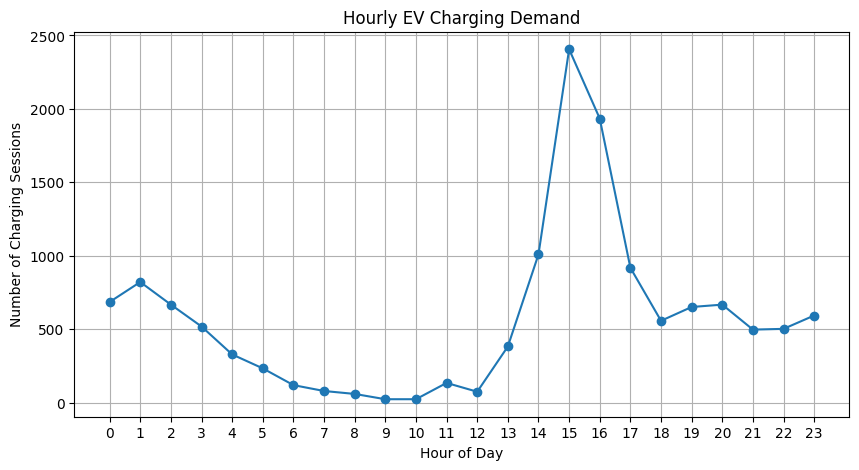

In [8]:
# Aggregate sessions by hour
hourly_demand = (
    df_clean
    .groupby('hour')
    .size()
)

# Plot
plt.figure(figsize=(10,5))

plt.plot(
    hourly_demand.index,
    hourly_demand.values,
    marker='o'
)

plt.xlabel("Hour of Day")
plt.ylabel("Number of Charging Sessions")
plt.title("Hourly EV Charging Demand")

plt.xticks(range(24))

plt.grid(True)

plt.show()

### Weekday vs Weekend Demand Analysis

- Charging behavior was compared between weekdays and weekends to identify differences in network utilization patterns.  
- Metrics such as total charging sessions, average energy consumption, and average idle time were analyzed.  
- The visualization highlights temporal variations in charging demand and helps evaluate commuter-driven usage behavior.  



            total_sessions  avg_energy_kwh  avg_idle_time
is_weekend                                               
0                    11417        8.776029     153.581079
1                     2462        9.338285      69.505449


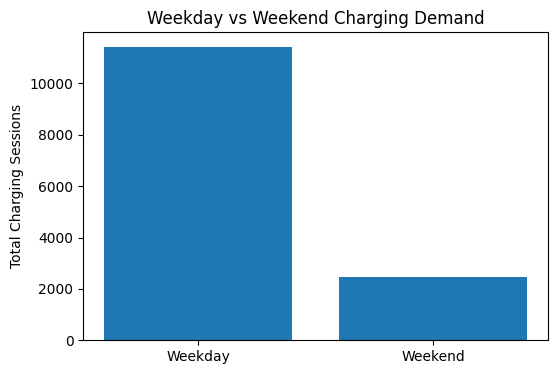

In [9]:
# Average sessions by weekend flag
weekend_analysis = (
    df_clean
    .groupby('is_weekend')
    .agg(
        total_sessions=('stationID', 'count'),
        avg_energy_kwh=('kWhDelivered', 'mean'),
        avg_idle_time=('idle_time_min', 'mean')
    )
)

print(weekend_analysis)


# Sessions comparison
plt.figure(figsize=(6,4))

plt.bar(
    ['Weekday', 'Weekend'],
    weekend_analysis['total_sessions']
)

plt.ylabel("Total Charging Sessions")
plt.title("Weekday vs Weekend Charging Demand")

plt.show()

### Station-Level Utilization Analysis

- Charging activity was aggregated at the station level to evaluate infrastructure utilization and operational efficiency.  
- Key metrics such as total charging sessions, total energy delivered, average utilization, and idle time were analyzed for each station.  
- The top utilized charging stations were identified to detect high-demand locations and potential congestion hotspots.  


             total_sessions  total_energy  avg_utilization  avg_idle_time
stationID                                                                
2-39-139-28             640   5403.753893         0.906885      92.459437
2-39-131-30             516   4574.772558         0.923349      96.248700
2-39-129-17             497   4275.742634         0.922062      95.966498
2-39-127-19             491   4168.347416         0.884275      96.389322
2-39-125-21             475   3733.168093         0.860921      99.734211
2-39-138-29             475   4016.449058         0.919073      97.055879
2-39-89-25              448   3806.008333         0.917780     151.099682
2-39-123-23             419   3338.662097         0.900329     128.488434
2-39-130-31             414   3353.580652         0.896002      84.191121
2-39-79-380             393   3413.755426         0.943764     173.052078


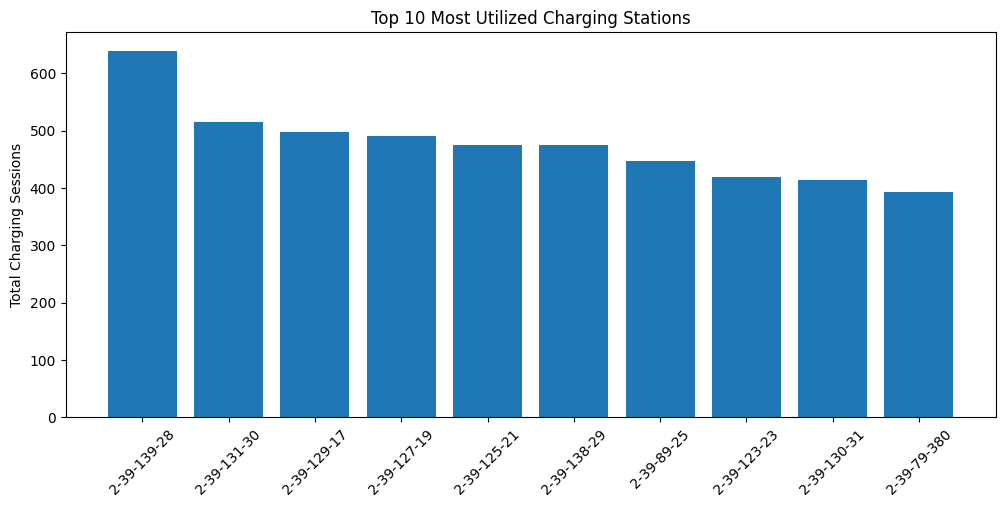

In [10]:
# Station-level utilization summary
station_analysis = (
    hourly_df
    .groupby('stationID')
    .agg(
        total_sessions=('session_count', 'sum'),
        total_energy=('total_energy_kwh', 'sum'),
        avg_utilization=('utilization_rate', 'mean'),
        avg_idle_time=('avg_idle_time_min', 'mean')
    )
    .sort_values(
        by='total_sessions',
        ascending=False
    )
)

# Top 10 busiest stations
top_stations = station_analysis.head(10)

print(top_stations)




plt.figure(figsize=(12,5))

plt.bar(
    top_stations.index.astype(str),
    top_stations['total_sessions']
)

plt.xticks(rotation=45)

plt.ylabel("Total Charging Sessions")

plt.title("Top 10 Most Utilized Charging Stations")

plt.show()

### Charging Demand Heatmap Analysis

- A heatmap was created to visualize charging demand intensity across different days of the week and hours of the day.  
- This visualization helps identify:
  - peak congestion periods,
  - high-demand charging windows,
  - and temporal utilization patterns.  

- Darker regions indicate higher charging activity and potential congestion hotspots within the charging network.  



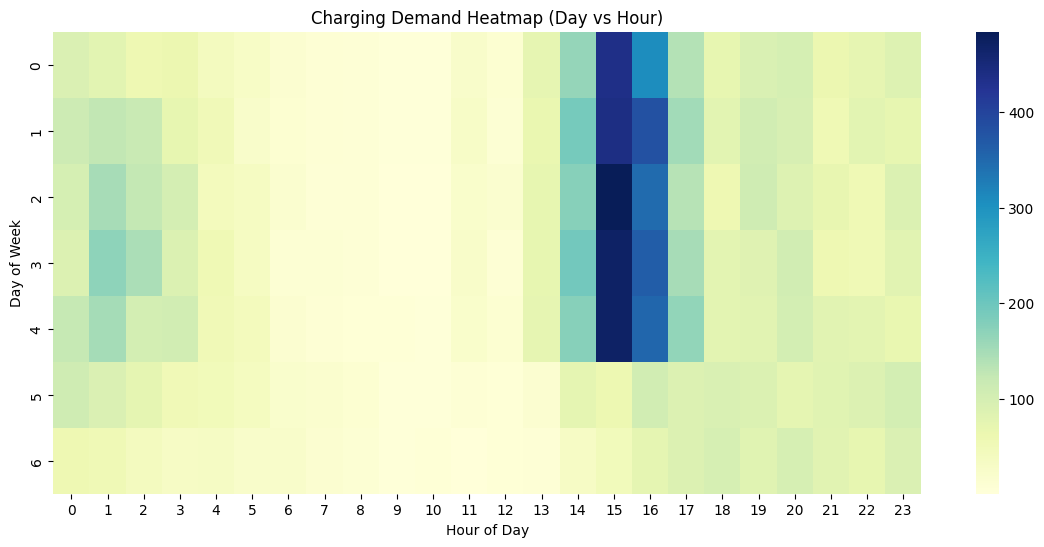

In [11]:


# Create pivot table
heatmap_data = (
    df_clean
    .groupby(['day_of_week', 'hour'])
    .size()
    .unstack(fill_value=0)
)

# Plot
plt.figure(figsize=(14,6))

sns.heatmap(
    heatmap_data,
    cmap='YlGnBu',
    annot=False
)

plt.title("Charging Demand Heatmap (Day vs Hour)")

plt.xlabel("Hour of Day")
plt.ylabel("Day of Week")

plt.show()
# 0 = Monday
# 6 = Sunday

### Revenue vs Utilization Analysis

- Station-level revenue and utilization metrics were analyzed to examine the relationship between charger usage intensity and revenue generation.  
- The scatter plot helps identify:
  - highly utilized high-revenue stations,
  - underperforming infrastructure,
  - and operational efficiency variations across charging stations.  



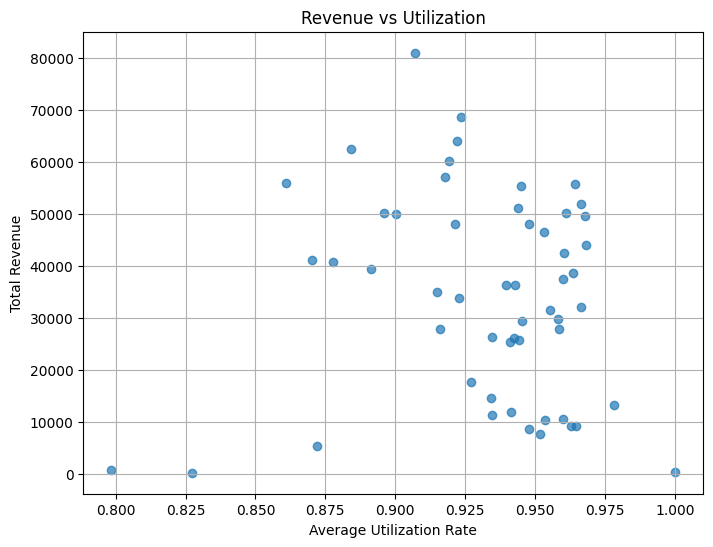

In [12]:


# Station-level revenue/utilization analysis
rev_util = (
    hourly_df
    .groupby('stationID')
    .agg(
        total_revenue=('total_revenue', 'sum'),
        avg_utilization=('utilization_rate', 'mean')
    )
)

# Scatter plot
plt.figure(figsize=(8,6))

plt.scatter(
    rev_util['avg_utilization'],
    rev_util['total_revenue'],
    alpha=0.7
)

plt.xlabel("Average Utilization Rate")
plt.ylabel("Total Revenue")

plt.title("Revenue vs Utilization")

plt.grid(True)

plt.show()

### Building the Demand Forecasting Dataset

- Charging sessions were aggregated at the hourly level to create a time-series demand dataset for forecasting analysis.  
- The total number of charging sessions per hour was used as the primary demand indicator.  
- Chronological sorting ensures proper temporal ordering required for time-series modeling and predictive analysis.  



In [13]:
# Aggregate total sessions per hour
demand_df = (
    hourly_df
    .groupby('timestamp_hour')
    .agg(
        total_sessions=('session_count', 'sum')
    )
    .reset_index()
)

# Sort chronologically
demand_df = demand_df.sort_values('timestamp_hour')

# Preview
print(demand_df.shape)

demand_df.head()

(3882, 2)


,timestamp_hour,total_sessions
0,2018-04-25 13:00:00,2
1,2018-04-25 14:00:00,5
2,2018-04-25 15:00:00,14
3,2018-04-25 16:00:00,8
4,2018-04-25 17:00:00,1


### Feature Engineering for Demand Forecasting

- Temporal and historical demand features were created to capture charging behavior patterns over time.  
- Time-based features such as hour, day of week, and month help model daily and weekly charging trends.  
- Lag variables were introduced to capture short-term and daily demand dependencies.  
- Rolling averages were used to smooth fluctuations and identify underlying demand trends.  

In [14]:
# Create time features
demand_df['hour'] = demand_df['timestamp_hour'].dt.hour
demand_df['day_of_week'] = demand_df['timestamp_hour'].dt.dayofweek
demand_df['month'] = demand_df['timestamp_hour'].dt.month

# Lag features
demand_df['lag_1'] = demand_df['total_sessions'].shift(1)
demand_df['lag_24'] = demand_df['total_sessions'].shift(24)

# Rolling averages
demand_df['rolling_mean_6'] = (
    demand_df['total_sessions']
    .rolling(window=6)
    .mean()
)

demand_df['rolling_mean_24'] = (
    demand_df['total_sessions']
    .rolling(window=24)
    .mean()
)

# Drop NaNs caused by lagging
demand_df = demand_df.dropna()

# Check
print(demand_df.shape)

demand_df.head()

(3858, 9)


,timestamp_hour,total_sessions,hour,day_of_week,month,lag_1,lag_24,rolling_mean_6,rolling_mean_24
24,2018-04-26 23:00:00,1,23,3,4,2.0,2.0,1.833333,3.791667
25,2018-04-27 01:00:00,4,1,4,4,1.0,5.0,1.833333,3.750000
26,2018-04-27 02:00:00,1,2,4,4,4.0,14.0,1.833333,3.208333
27,2018-04-27 03:00:00,2,3,4,4,1.0,8.0,2.000000,2.958333
28,2018-04-27 05:00:00,1,5,4,4,2.0,1.0,1.833333,2.958333


### Demand Forecasting Using Random Forest

- A Random Forest Regressor was used to predict hourly EV charging demand based on temporal and historical usage patterns.  
- Features such as lag variables, rolling averages, and time-based indicators were used to capture demand dynamics and charging behavior trends.  
- A time-series train-test split was applied to preserve chronological order and avoid data leakage during model evaluation.  

Model performance was evaluated using:
- MAE (Mean Absolute Error),
- RMSE (Root Mean Squared Error),
- and R² Score.

In [15]:
# Features
features = [
    'hour',
    'day_of_week',
    'month',
    'lag_1',
    'lag_24',
    'rolling_mean_6',
    'rolling_mean_24'
]

X = demand_df[features]

y = demand_df['total_sessions']

# Time-series split
split_index = int(len(demand_df) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

# Model
model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

# Train
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Metrics
mae = mean_absolute_error(y_test, y_pred)

rmse = mean_squared_error(
    y_test,
    y_pred
) ** 0.5

r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("RMSE:", rmse)
print("R2  :", r2)

MAE : 1.3724589810017271
RMSE: 1.9929481888520018
R2  : 0.673019070341402


### Actual vs Predicted Demand Visualization

- Actual and predicted charging demand values were visualized to evaluate forecasting performance over time.  
- The comparison helps assess how well the Random Forest model captures temporal demand patterns and fluctuations in EV charging activity.  
- Close alignment between the two curves indicates strong predictive performance and effective learning of charging behavior dynamics.

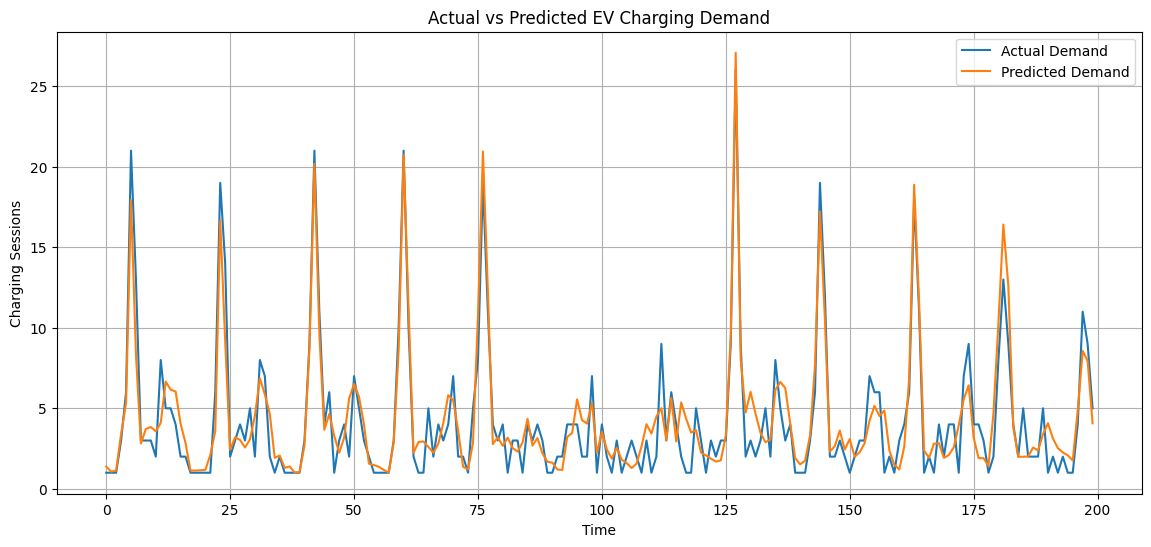

In [16]:


# Plot actual vs predicted
plt.figure(figsize=(14,6))

plt.plot(
    y_test.values[:200],
    label='Actual Demand'
)

plt.plot(
    y_pred[:200],
    label='Predicted Demand'
)

plt.xlabel("Time")

plt.ylabel("Charging Sessions")

plt.title("Actual vs Predicted EV Charging Demand")

plt.legend()

plt.grid(True)

plt.show()

### Dynamic Tariff Optimization

- A rule-based dynamic pricing strategy was implemented using charger utilization levels.  
- Surge pricing was applied during high-congestion periods, while discount pricing was used during low-utilization intervals.  
- Revenue under adaptive pricing was compared against baseline static pricing to evaluate pricing effectiveness and monetization improvement.  

The pricing framework includes:
- ₹22/kWh during high utilization,
- ₹15/kWh under normal conditions,
- and ₹10/kWh during low-demand periods.

In [17]:
# Base tariff
BASE_PRICE = 15

def dynamic_price(utilization):

    if utilization >= 0.8:
        return 22      # Surge pricing

    elif utilization <= 0.3:
        return 10      # Discount pricing

    else:
        return 15      # Normal pricing

# Apply pricing policy
hourly_df['dynamic_tariff'] = (
    hourly_df['utilization_rate']
    .apply(dynamic_price)
)

# Dynamic revenue
hourly_df['dynamic_revenue'] = (
    hourly_df['total_energy_kwh'] *
    hourly_df['dynamic_tariff']
)

# Revenue uplift
hourly_df['revenue_gain_pct'] = (
    (
        hourly_df['dynamic_revenue'] -
        hourly_df['total_revenue']
    )
    / hourly_df['total_revenue']
) * 100

# Quick check
hourly_df[[
    'utilization_rate',
    'dynamic_tariff',
    'total_revenue',
    'dynamic_revenue',
    'revenue_gain_pct'
]].head()

,utilization_rate,dynamic_tariff,total_revenue,dynamic_revenue,revenue_gain_pct
0,1.0,22,78.855,115.654,46.666667
1,1.0,22,150.195,220.286,46.666667
2,1.0,22,118.650,174.020,46.666667
3,1.0,22,104.295,152.966,46.666667
4,1.0,22,77.655,113.894,46.666667


### Revenue Uplift Evaluation

- Total revenue generated under baseline static pricing was compared with revenue obtained using the dynamic tariff strategy.  
- Revenue uplift percentage was calculated to measure the financial impact of congestion-aware adaptive pricing.  
- This evaluation helps assess the effectiveness of dynamic tariff optimization in improving monetization and infrastructure efficiency.

In [18]:
# Total baseline revenue
baseline_total = (
    hourly_df['total_revenue']
    .sum()
)

# Total dynamic revenue
dynamic_total = (
    hourly_df['dynamic_revenue']
    .sum()
)

# Revenue uplift %
uplift_pct = (
    (
        dynamic_total -
        baseline_total
    )
    / baseline_total
) * 100

print("Baseline Revenue :", baseline_total)
print("Dynamic Revenue  :", dynamic_total)
print("Revenue Uplift % :", uplift_pct)

Baseline Revenue : 1847801.6762067631
Dynamic Revenue  : 2681441.472917661
Revenue Uplift % : 45.11522028826303


### Dynamic Tariff Distribution Analysis

- The frequency of different tariff levels was analyzed to understand how often surge, normal, and discount pricing conditions occurred across the charging network.  
- The distribution highlights the balance between congestion periods and underutilized intervals within the infrastructure.  
- This analysis helps evaluate pricing stability, congestion intensity, and the operational effectiveness of the adaptive tariff strategy.

dynamic_tariff
10      363
15     1411
22    12029
Name: count, dtype: int64


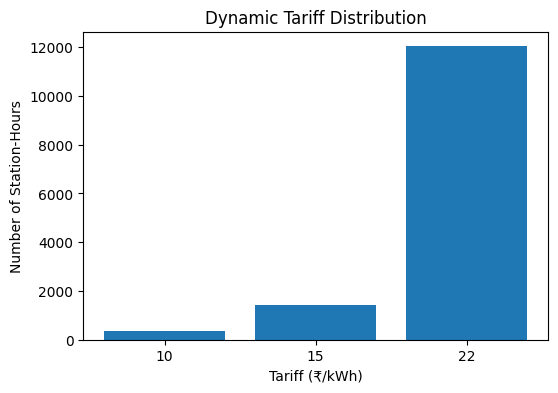

In [19]:


# Tariff frequency
tariff_counts = (
    hourly_df['dynamic_tariff']
    .value_counts()
    .sort_index()
)

print(tariff_counts)

# Plot
plt.figure(figsize=(6,4))

plt.bar(
    tariff_counts.index.astype(str),
    tariff_counts.values
)

plt.xlabel("Tariff (₹/kWh)")
plt.ylabel("Number of Station-Hours")

plt.title("Dynamic Tariff Distribution")

plt.show()

### Pricing Efficiency Evaluation

- Pricing efficiency was measured as revenue generated per unit of energy delivered under both baseline and dynamic pricing strategies.  
- Comparing these efficiency values helps evaluate the financial effectiveness of adaptive tariff optimization.  
- Higher dynamic pricing efficiency indicates improved monetization and better utilization of charging infrastructure.

In [20]:
# Baseline pricing efficiency
baseline_efficiency = (
    hourly_df['total_revenue'].sum()
    /
    hourly_df['total_energy_kwh'].sum()
)

# Dynamic pricing efficiency
dynamic_efficiency = (
    hourly_df['dynamic_revenue'].sum()
    /
    hourly_df['total_energy_kwh'].sum()
)

print("Baseline Pricing Efficiency :", baseline_efficiency)
print("Dynamic Pricing Efficiency  :", dynamic_efficiency)

Baseline Pricing Efficiency : 15.000000000000002
Dynamic Pricing Efficiency  : 21.767283043239456


### Congestion Classification Analysis

- Charging intervals were categorized into high congestion, normal utilization, and low-utilization states based on charger utilization rates.  
- This classification helps identify operational stress levels and charging demand intensity across the network.  
- The congestion summary provides insights into infrastructure pressure and the frequency of surge pricing conditions.

In [21]:
# Congestion categories
def congestion_level(util):

    if util >= 0.8:
        return 'High Congestion'

    elif util <= 0.3:
        return 'Low Utilization'

    else:
        return 'Normal'

# Apply classification
hourly_df['congestion_status'] = (
    hourly_df['utilization_rate']
    .apply(congestion_level)
)

# Count categories
congestion_summary = (
    hourly_df['congestion_status']
    .value_counts()
)

print(congestion_summary)

congestion_status
High Congestion    12029
Normal              1411
Low Utilization      363
Name: count, dtype: int64


### Charging Network Congestion Monitoring

- A congestion monitoring chart was created to visualize the distribution of charging intervals across different utilization categories.  
- The visualization highlights the frequency of:
  - high congestion periods,
  - normal operating conditions,
  - and low-utilization intervals.  

- This monitoring framework helps evaluate infrastructure stress levels and the effectiveness of adaptive pricing strategies.

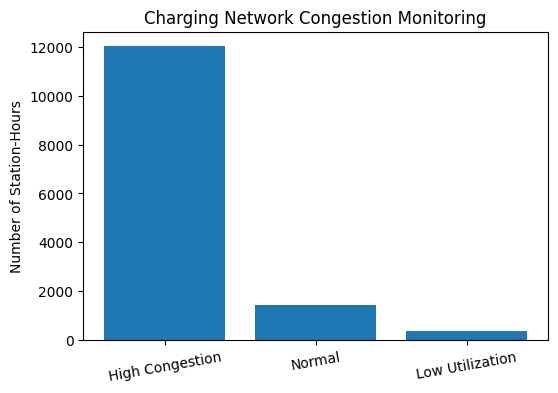

In [22]:
plt.figure(figsize=(6,4))

plt.bar(
    congestion_summary.index,
    congestion_summary.values
)

plt.ylabel("Number of Station-Hours")

plt.title("Charging Network Congestion Monitoring")

plt.xticks(rotation=10)

plt.show()